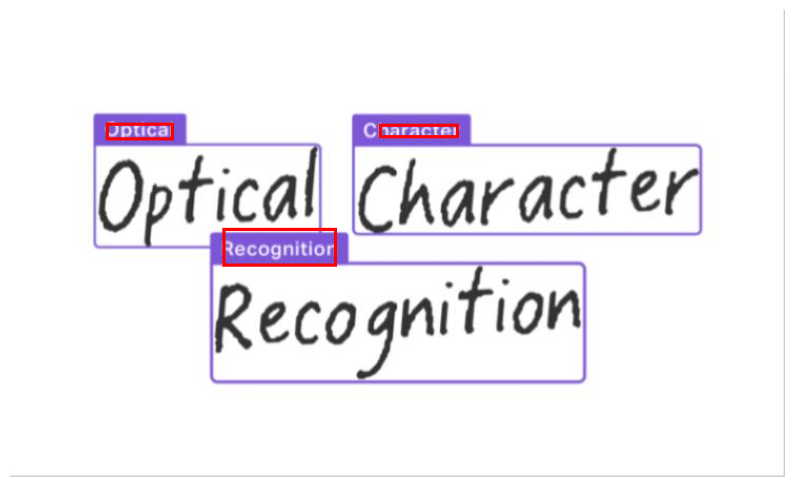

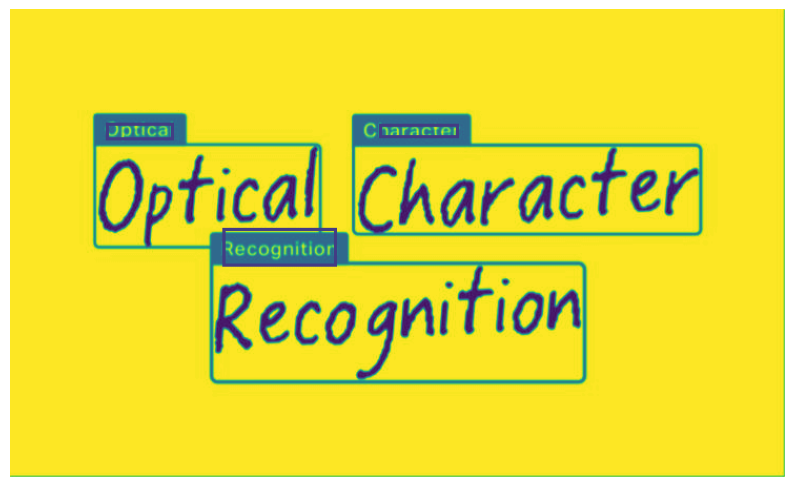

In [13]:
from pytesseract import pytesseract, Output
import numpy as np
from PIL import Image, ImageOps, ImageFilter, ImageDraw
from matplotlib import pyplot as plt

imagePrev = Image.open('images/ocr.png')
pytesseract.tesseract_cmd = r"D:\Apps\Tesseract\tesseract.exe"


def get_location_of_text_file(img):

    data = pytesseract.image_to_data(img, output_type=Output.DICT)
    locations = []
    n_boxes = len(data['text'])
    for i in range(n_boxes):
        text = data['text'][i].strip()
        if text != "":
            x, y, w, h = data['left'][i], data['top'][i], data['width'][i], data['height'][i]
            locations.append((x, y, x + w, y + h))
    return locations

def image_with_box_surrounding_text(image):
    locations = get_location_of_text_file(image)
    draw = ImageDraw.Draw(image)

    for location in locations:
        x1, y1, x2, y2 = location
        draw.rectangle([x1, y1, x2, y2], outline=(255, 0, 0), width=3)

    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

#metode de imbunatatire

def normalization(image):
    gray = ImageOps.grayscale(image)
    arr = np.array(gray, dtype=np.float32)
    arr_norm = 255 * (arr - arr.min()) / (arr.max() - arr.min())
    return Image.fromarray(arr_norm.astype(np.uint8))
image_with_box_surrounding_text(imagePrev)
image_with_box_surrounding_text(normalization(imagePrev))


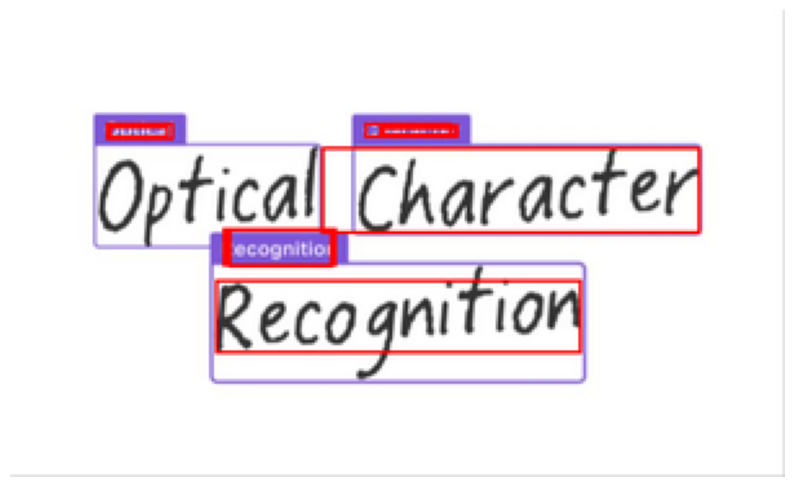

In [16]:
def image_scaling(image):
    width, height = image.size
    current_resolution = max(width, height)
    factor = 300 / current_resolution
    new_width = int(width * factor)
    new_height = int(height * factor)
    return image.resize((new_width, new_height), Image.Resampling.LANCZOS)

image_with_box_surrounding_text(image_scaling(imagePrev))
text = pytesseract.image_to_string(image_scaling(imagePrev))
print(text)


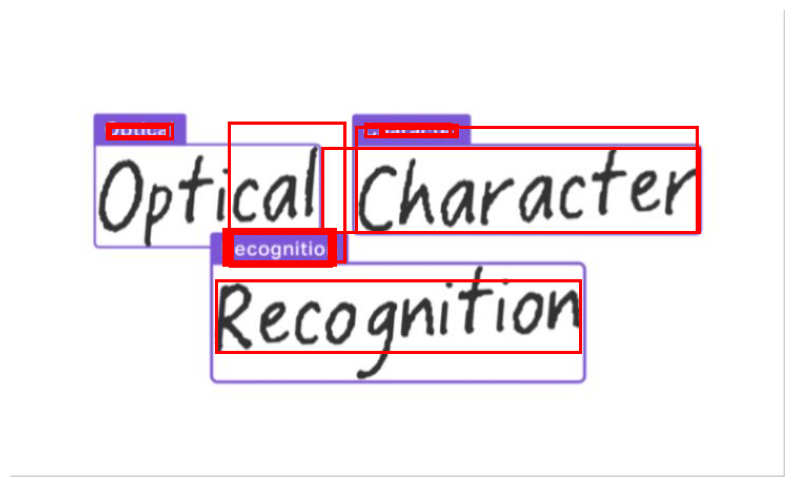

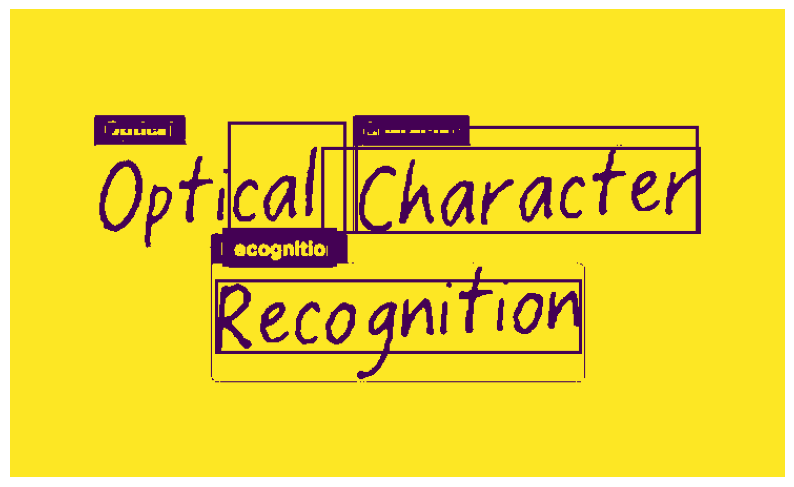

In [18]:
def binarization(image):
    gray = ImageOps.grayscale(image)
    arr = np.array(gray)
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            arr[i, j] = 255 if arr[i, j] > 128 else 0
    return Image.fromarray(arr)

image_with_box_surrounding_text(imagePrev)
image_with_box_surrounding_text(binarization(imagePrev))
text = pytesseract.image_to_string(binarization(imagePrev))
print(text)
